From the [Muon Tutorials for Single-cell RNA-seq and ATAC-seq integration](https://muon-tutorials.readthedocs.io/en/latest/single-cell-rna-atac/pbmc10k/1-Gene-Expression-Processing.html)

In [1]:
# Single-cell packages
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import anndata as ad
import pysam
import scvi  # SCANVI reference-based cell type transfer

from pathlib import Path

# General helpful packages for data analysis and visualization
import pandas as pd
import scanpy as sc
import seaborn as sns
from muon import atac as ac  # the module containing function for scATAC data processing

# Setting figure parameters
sc.settings.verbosity = 0

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")
PROJECT_DATA_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER")

ORGANISM_CODE = "mm10"
CELL_TYPE = "mouse_liver"
DATASET_NAME = "mouse_liver_10x_raw"
SAMPLE_NAME = "liver_sample"
RAW_DATA_DIR = PROJECT_DATA_DIR / "RAW_DATA" / DATASET_NAME
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed" / CELL_TYPE

def default_tss_bed(species):
    """Prefer <species>_gene_tss.bed -- that is what the existing samples were built with."""
    annotation_dir = PROJECT_DIR / "data" / "genome_data" / "genome_annotation" / species
    preferred = annotation_dir / f"{species}_gene_tss.bed"
    return preferred if preferred.exists() else annotation_dir / "gene_tss.bed"

tss_path = default_tss_bed(ORGANISM_CODE)

# Set to None if you have 10X files instead of count files
rna_count_file = None
atac_count_file = None

# Set to None if you have matrix, features, barcode files instead of an h5 file
raw_h5_file = RAW_DATA_DIR / "GSE288579_filtered_feature_bc_matrix.h5"

# If you want to keep all TFs to maximize overlap with the ground truth files, pass in a ground truth file path here.
tf_list_file = None

# If you are running with 10X, replace None with the path to your indexed fragment file (for nucleosome signal filtering)
frag_path = None

SAMPLE_DATA_DIR = RAW_DATA_DIR / SAMPLE_NAME
SAMPLE_PROCESSED_DATA_DIR = PROCESSED_DATA_DIR / SAMPLE_NAME

if not SAMPLE_PROCESSED_DATA_DIR.exists():
    SAMPLE_PROCESSED_DATA_DIR.mkdir(parents=True)

print(f"Loading data for sample {SAMPLE_NAME} from {RAW_DATA_DIR}...")
# print all files in the data directory
for file in SAMPLE_DATA_DIR.glob("*"):
    print(f"  - {file.name}")
    file_end = file.name.split("_")[-1]
    print(file_end)
    if file_end.endswith("barcodes.tsv.gz"):
        file.rename(SAMPLE_DATA_DIR / f"barcodes.tsv.gz")
    elif file_end.endswith("features.tsv.gz"):
        file.rename(SAMPLE_DATA_DIR / f"features.tsv.gz")
    elif file_end.endswith("matrix.mtx.gz"):
        file.rename(SAMPLE_DATA_DIR / f"matrix.mtx.gz")
    elif file_end.endswith("fragments.tsv.gz"):
        file.rename(SAMPLE_DATA_DIR / f"fragments.tsv.gz")
    elif file_end.endswith("fragments.tsv.gz.tbi"):
        file.rename(SAMPLE_DATA_DIR / f"fragments.tsv.gz.tbi")
        

2026-09-25 10:52:55.701271: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-25 10:53:01.147720: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


Loading data for sample liver_sample from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA/mouse_liver_10x_raw...


## Load in the Raw Data

In [2]:
def normalize_peak_format(peak_id: str) -> str:
    """
    Normalize peak format from chrN-start-end or chrN:start:end to chrN:start-end.
    Handles both formats as input and always outputs chrN:start-end.
    """
    if not isinstance(peak_id, str):
        return peak_id
    
    # Try to parse chr-start-end format (with dashes)
    parts = peak_id.split('-')
    if len(parts) >= 3:
        # Assume format is chr-start-end where chr might have dashes
        # Work backwards: the last two parts are start and end
        try:
            end = int(parts[-1])
            start = int(parts[-2])
            chrom = '-'.join(parts[:-2])  # Everything before the last two parts
            return f"{chrom}:{start}-{end}"
        except (ValueError, IndexError):
            pass
    
    # Already in chr:start-end format or some other format, return as-is
    return peak_id

def construct_from_gene_by_cell_matrices(rna_count_file, atac_count_file):
    assert rna_count_file.exists(), "rna count file does not exist"
    assert atac_count_file.exists(), "atac count file does not exist"
    
    rna_count_matrix = pd.read_csv(rna_count_file, header=0, index_col=0)
    atac_count_matrix = pd.read_csv(atac_count_file, header=0, index_col=0)
    
    rna_matrix = rna_count_matrix.T.values
    rna_metadata_df = pd.DataFrame(index=rna_count_matrix.columns)
    rna_features_df = pd.DataFrame(index=rna_count_matrix.index)
    
    atac_count_matrix.index = atac_count_matrix.index.map(normalize_peak_format)

    atac_matrix = atac_count_matrix.T.values
    atac_metadata_df = pd.DataFrame(index=atac_count_matrix.columns)
    atac_features_df = pd.DataFrame(index=atac_count_matrix.index)
    
    adata_rna = ad.AnnData(X=rna_matrix, obs=rna_metadata_df, var=rna_features_df)
    adata_rna.var["feature_types"] = "Gene Expression"
    adata_rna.var["gene_ids"] = adata_rna.var_names

    adata_atac = ad.AnnData(X=atac_matrix, obs=atac_metadata_df, var=atac_features_df)
    adata_atac.var["feature_types"] = "Peaks"
    adata_atac.var["gene_ids"] = adata_atac.var_names

    mdata = mu.MuData({'rna': adata_rna, 'atac': adata_atac})

    return mdata

def filter_to_human(mdata):
    """
    Filter a barnyard MuData object to hg38 ATAC peaks only,
    then strip the 'hg38.' prefix from peak IDs.
    """
    if "hg38" in mdata["atac"].var_names[0]:
        # annotate species from interval
        mdata["atac"].var["species"] = (
            mdata["atac"].var["interval"].str.split(".", n=1).str[0]
        )

        # keep only hg38 peaks
        hg38_mask = mdata["atac"].var["species"] == "hg38"
        mdata.mod["atac"] = mdata["atac"][:, hg38_mask].copy()

        # strip prefix from identifiers
        mdata.mod["atac"].var_names = (
            mdata.mod["atac"].var_names.str.replace(r"^hg38\.", "", regex=True)
        )
        mdata.mod["atac"].var["gene_ids"] = (
            mdata.mod["atac"].var["gene_ids"].str.replace(r"^hg38\.", "", regex=True)
        )
        mdata.mod["atac"].var["interval"] = (
            mdata.mod["atac"].var["interval"].str.replace(r"^hg38\.", "", regex=True)
        )
        mdata = mu.MuData(mdata.mod)

    return mdata

Build the mdata object, either from raw 10X genomic data, a 10x h5 file, or from a counts file. If you build from counts files, you won't be able to run the ATAC-seq QC filtering steps that require fragment files.

In [3]:
if rna_count_file is not None and atac_count_file is not None:
    rna_count_filepath = SAMPLE_DATA_DIR / rna_count_file
    atac_count_filepath = SAMPLE_DATA_DIR / atac_count_file
    
    mdata = construct_from_gene_by_cell_matrices(rna_count_filepath, atac_count_filepath)
    print("Constructed MuData object from count files.")
elif raw_h5_file is not None:
    mdata = mu.read_10x_h5(raw_h5_file)
else:
    mdata = mu.read_10x_mtx(SAMPLE_DATA_DIR)
        
mdata.var_names_make_unique()
display(mdata)

mdata.write(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from /gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/RAW_DATA/mouse_liver_10x_raw/GSE288579_filtered_feature_bc_matrix.h5


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:571: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/sit

MuData object with n_obs × n_vars = 24936 × 181678
  var:	'gene_ids', 'feature_types', 'genome', 'interval'
  2 modalities
    rna:	24936 x 32285
      var:	'gene_ids', 'feature_types', 'genome', 'interval'
    atac:	24936 x 149393
      var:	'gene_ids', 'feature_types', 'genome', 'interval'

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## Assign each mouse an observation

In [ ]:
mdata.obs["donor"] = "mouse_" + mdata.obs_names.str.rsplit("-", n=1).str[1]

# RNA

In [5]:
rna = mdata.mod['rna']
rna

AnnData object with n_obs × n_vars = 24936 × 32285
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

## Preprocessing

### QC

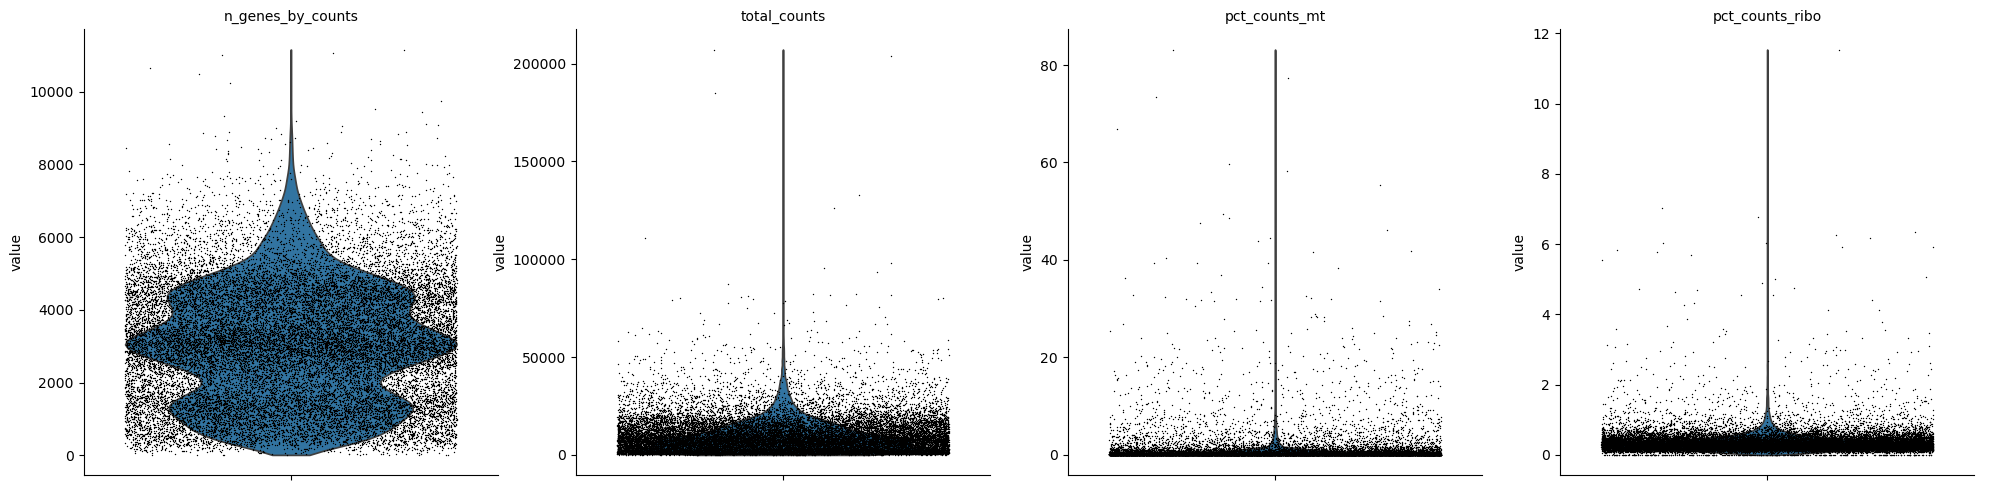

In [6]:
rna.var['mt'] = rna.var_names.str.upper().str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
rna.var['ribo'] = rna.var_names.str.upper().str.startswith('RPL') | rna.var_names.str.upper().str.startswith('RPS')  # annotate the group of ribosomal genes as 'ribo'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt', 'ribo'], percent_top=[20], log1p=True, inplace=True)

sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
             jitter=0.4, multi_panel=True)

Filter genes and cells based on the thresholds above

In [7]:
from scipy.stats import median_abs_deviation

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

# Filter out cells that are out of 5 MADs
rna.obs["outlier"] = (
    is_outlier(rna, "log1p_total_counts", 5)
    | is_outlier(rna, "log1p_n_genes_by_counts", 5)
    | is_outlier(rna, "pct_counts_in_top_20_genes", 5)
)
rna.obs.outlier.value_counts()

outlier
False    23854
True      1082
Name: count, dtype: int64

In [8]:
rna.obs["mt_outlier"] = is_outlier(rna, "pct_counts_mt", 5) | (
    rna.obs["pct_counts_mt"] > 25
)
rna.obs.mt_outlier.value_counts()

mt_outlier
False    20441
True      4495
Name: count, dtype: int64

In [9]:
print(f"Total number of cells: {rna.n_obs}")
rna_filtered = rna[(~rna.obs.outlier) & (~rna.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {rna_filtered.n_obs}")

Total number of cells: 24936
Number of cells after filtering of low quality cells: 20277


In [10]:
print(f"Total number of genes: {rna_filtered.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(rna_filtered, min_cells=20)
print(f"Number of genes after cell filter: {rna_filtered.n_vars}")

Total number of genes: 32285
Number of genes after cell filter: 18960


Detect and remove doublets

In [11]:
sc.pp.scrublet(rna_filtered)

# Filter out doublets
rna_filtered = rna_filtered[~rna_filtered.obs["predicted_doublet"], :]
print(f"Number of genes after cell filter: {rna_filtered.n_vars}")

Number of genes after cell filter: 18960


Check to see how the data looks after filtering.

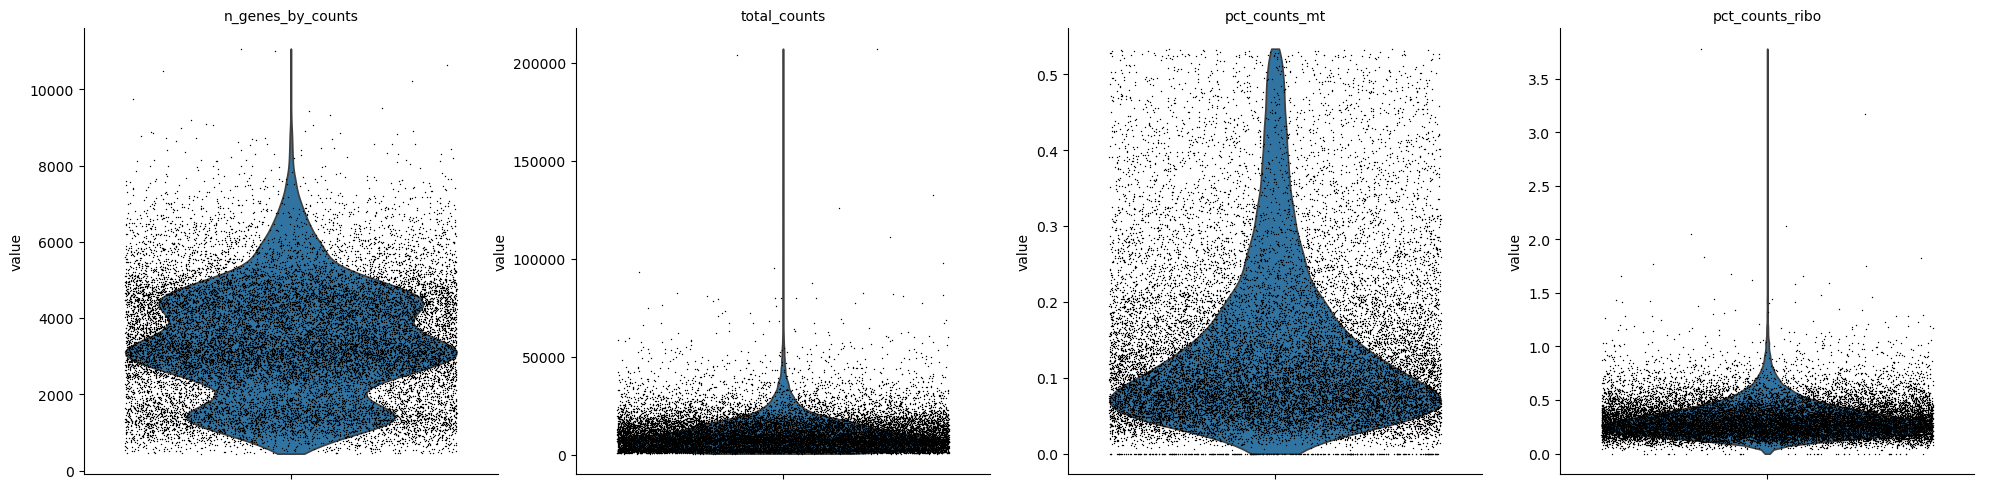

In [12]:
sc.pl.violin(rna_filtered, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
             jitter=0.4, multi_panel=True)

In [13]:
rna_filtered.layers["counts"] = rna_filtered.X.copy()

/tmp/ipykernel_3557312/1194632867.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  rna_filtered.layers["counts"] = rna_filtered.X.copy()


### Normalization

In [14]:
sc.pp.normalize_total(rna_filtered, target_sum=1e4)
sc.pp.log1p(rna_filtered)

### Feature Selection

We will label highly variable genes that we'll use for downstream analysis.

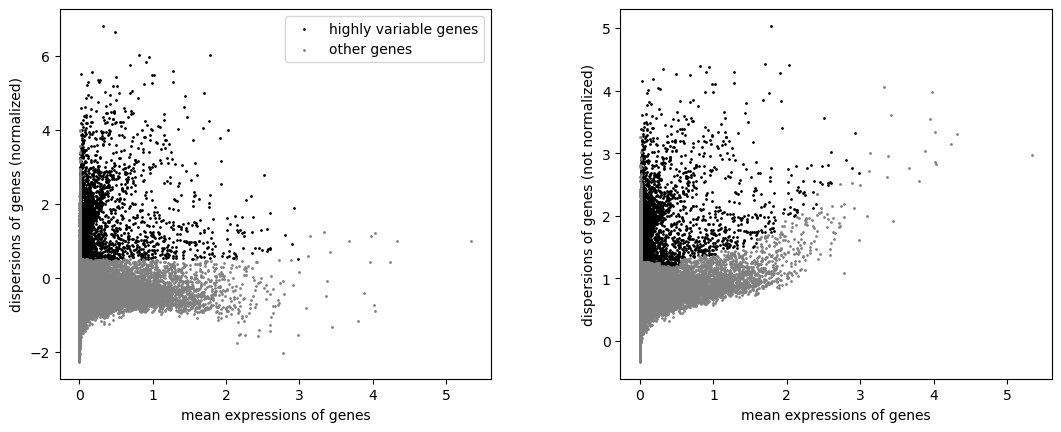

In [15]:
sc.pp.highly_variable_genes(rna_filtered)
sc.pl.highly_variable_genes(rna_filtered)

In [16]:
# keep_genes = rna_filtered.var["highly_variable"]
# rna_filtered = rna_filtered[:, keep_genes]
# np.sum(rna_filtered.var.highly_variable)

### Scaling

We'll save log-normalized counts in a `.raw` slot, then scale the log-normalized counts to zero mean and unit variance

['Xkr4', 'Sox17', 'Gm37587']


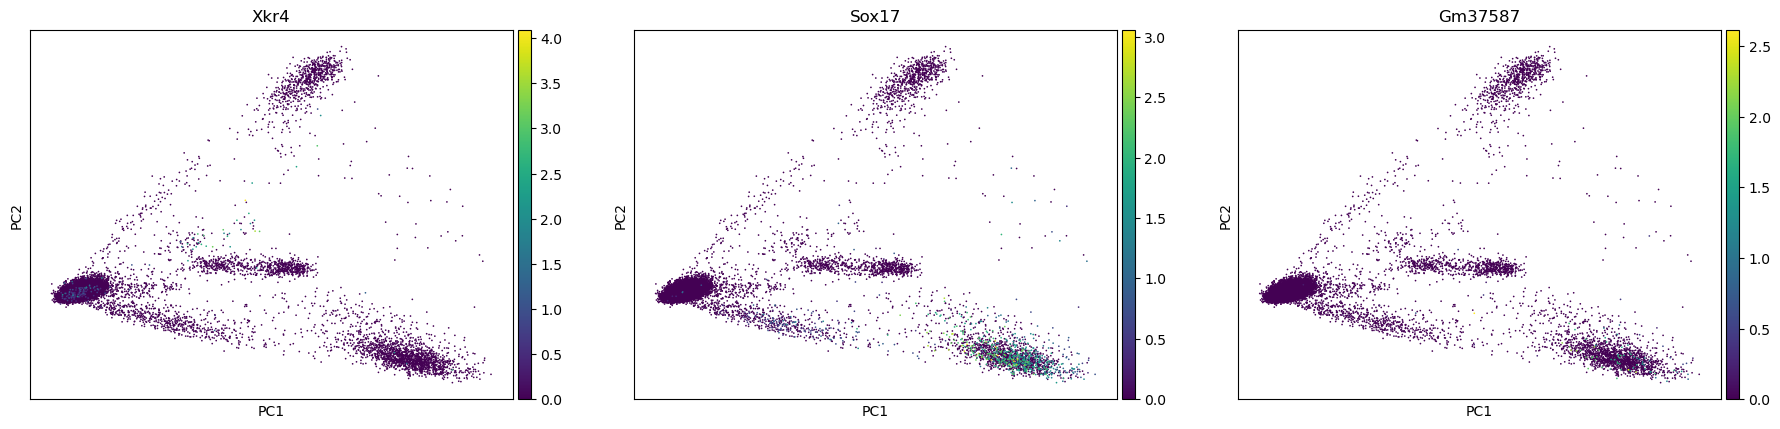

In [17]:
sc.tl.pca(rna_filtered, svd_solver='arpack')

first_three_hvg_genes = rna_filtered.var[rna_filtered.var.highly_variable].index[:3].to_list()
print(first_three_hvg_genes)

sc.pl.pca(rna_filtered, color=first_three_hvg_genes)

In [18]:
rna_filtered.obs["donor"] = "mouse_" + rna_filtered.obs_names.str.rsplit("-", n=1).str[1]

## Harmony integration

In [19]:
import harmonypy
import numpy as np

ho = harmonypy.run_harmony(
    rna_filtered.obsm["X_pca"].astype(np.float64),
    rna_filtered.obs,
    "donor",
)

Z = np.asarray(ho.Z_corr)
if Z.shape[0] != rna_filtered.n_obs:   # handles either orientation
    Z = Z.T

rna_filtered.obsm["X_pca_harmony"] = Z

2026-09-25 10:58:06,183 - harmonypy - INFO - Running Harmony
2026-09-25 10:58:06,184 - harmonypy - INFO -   Parameters:
2026-09-25 10:58:06,185 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-25 10:58:06,186 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-25 10:58:06,186 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-25 10:58:06,187 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-25 10:58:06,189 - harmonypy - INFO -     nclust: 100
2026-09-25 10:58:06,190 - harmonypy - INFO -     block_size: 0.05
2026-09-25 10:58:06,190 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-25 10:58:06,191 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-09-25 10:58:06,192 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-25 10:58:06,192 - harmonypy - INFO -     verbose: True
2026-09-25 10:58:06,193 - harmonypy - INFO -     random_state: 0
2026-09-25 10:58:06,194 - harmonypy - INFO -   Data: 50 PCs × 20277 cells
2026-09-25 10:58:06,194 - harmonypy - 

## Analysis

### PCA and Neighborhood Graph

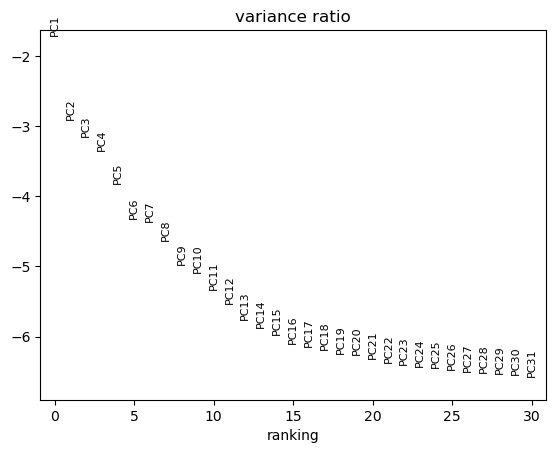

In [20]:
sc.pl.pca_variance_ratio(rna_filtered, log=True)

### Neighbors

In [21]:
sc.pp.pca(rna_filtered, svd_solver="arpack", mask_var="highly_variable")

sc.tl.tsne(rna_filtered, use_rep="X_pca")

### Non-linear dimensionality reduction and clustering

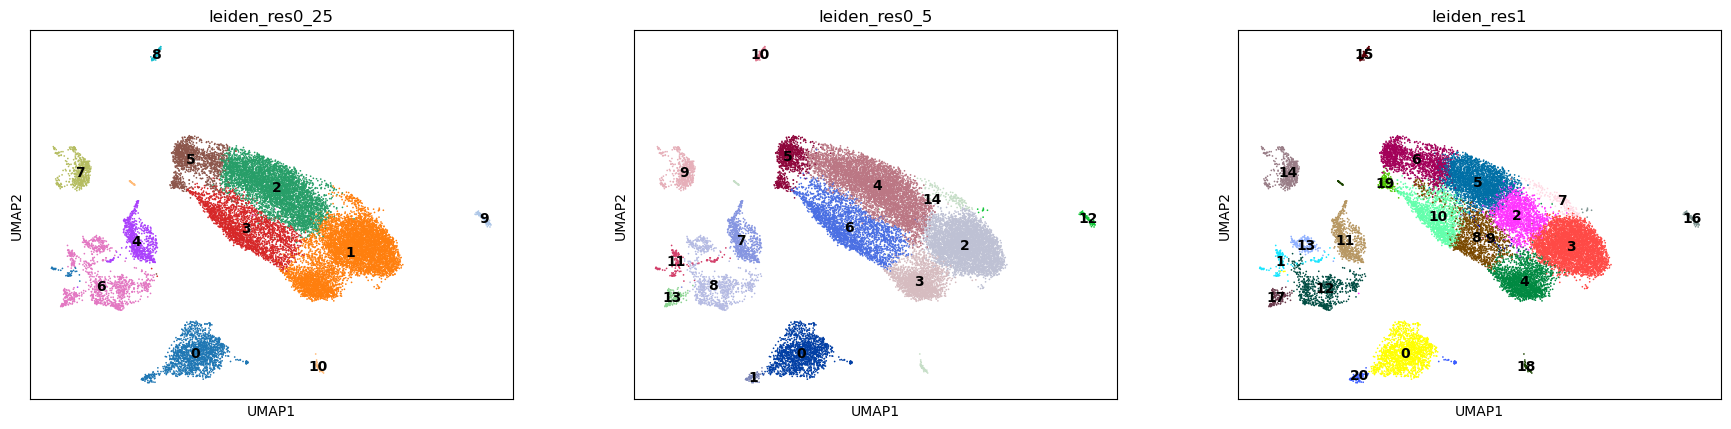

In [25]:
sc.pp.neighbors(rna_filtered, use_rep="X_pca_harmony", n_neighbors=8)
sc.tl.umap(rna_filtered, spread=1., min_dist=.5, random_state=11)

sc.tl.leiden(
    rna_filtered, key_added="leiden_res0_25", resolution=0.25, flavor="igraph", n_iterations=2
)
sc.tl.leiden(
    rna_filtered, key_added="leiden_res0_5", resolution=0.5, flavor="igraph", n_iterations=2
)
sc.tl.leiden(
    rna_filtered, key_added="leiden_res1", resolution=1.0, flavor="igraph", n_iterations=2
)

sc.pl.umap(
    rna_filtered,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
)

## Cell Type Mapping

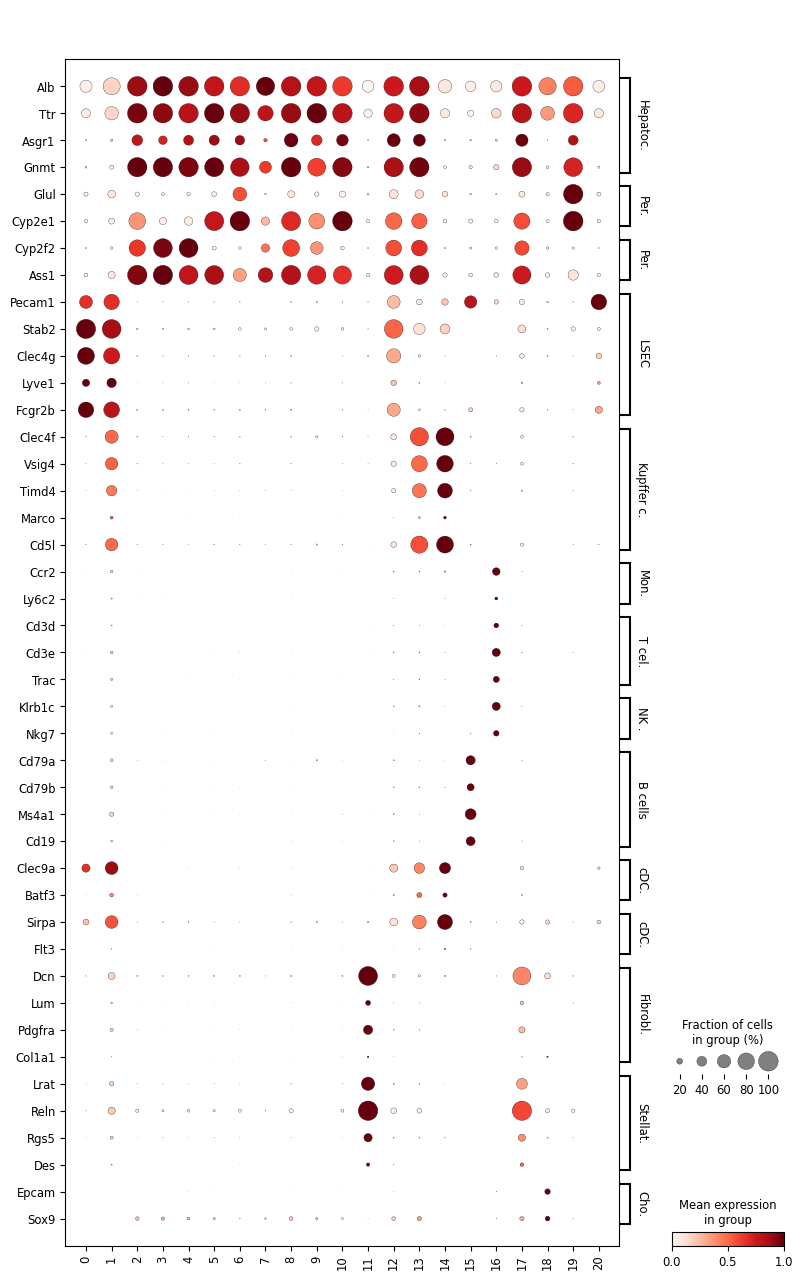

In [30]:
marker_dict = {
    "Hepatocytes": ["Alb", "Ttr", "Asgr1", "Gnmt"],
    "Pericentral": ["Glul", "Cyp2e1"],
    "Periportal": ["Cyp2f2", "Ass1"],
    "LSEC": ["Pecam1", "Stab2", "Clec4g", "Lyve1", "Fcgr2b"],
    "Kupffer cells": ["Clec4f", "Vsig4", "Timd4", "Marco", "Cd5l"],
    "Monocytes": ["Ccr2", "Ly6c2", "S100a8", "S100a9"],
    "T cells": ["Cd3d", "Cd3e", "Trac"],
    "NK cells": ["Ncr1", "Klrb1c", "Xcl1", "Nkg7"],
    "B cells": ["Cd79a", "Cd79b", "Ms4a1", "Cd19"],
    "cDC1": ["Xcr1", "Clec9a", "Batf3"],
    "cDC2": ["Sirpa", "Cd209a", "Flt3"],
    "Fibroblasts": ["Dcn", "Lum", "Pdgfra", "Col1a1"],
    "Stellate cells": ["Lrat", "Reln", "Rgs5", "Des"],
    "Cholangiocytes": ["Epcam", "Krt19", "Krt7", "Sox9"],
}

# Keep only genes present in the RNA object
marker_dict_present = {
    group: [g for g in genes if g in rna_filtered.var_names]
    for group, genes in marker_dict.items()
}

# Remove empty groups
marker_dict_present = {
    group: genes
    for group, genes in marker_dict_present.items()
    if len(genes) > 0
}

sc.pl.dotplot(
    rna_filtered,
    var_names=marker_dict_present,
    groupby="leiden_res1",
    standard_scale="var",
    dendrogram=False,
    swap_axes=True
)

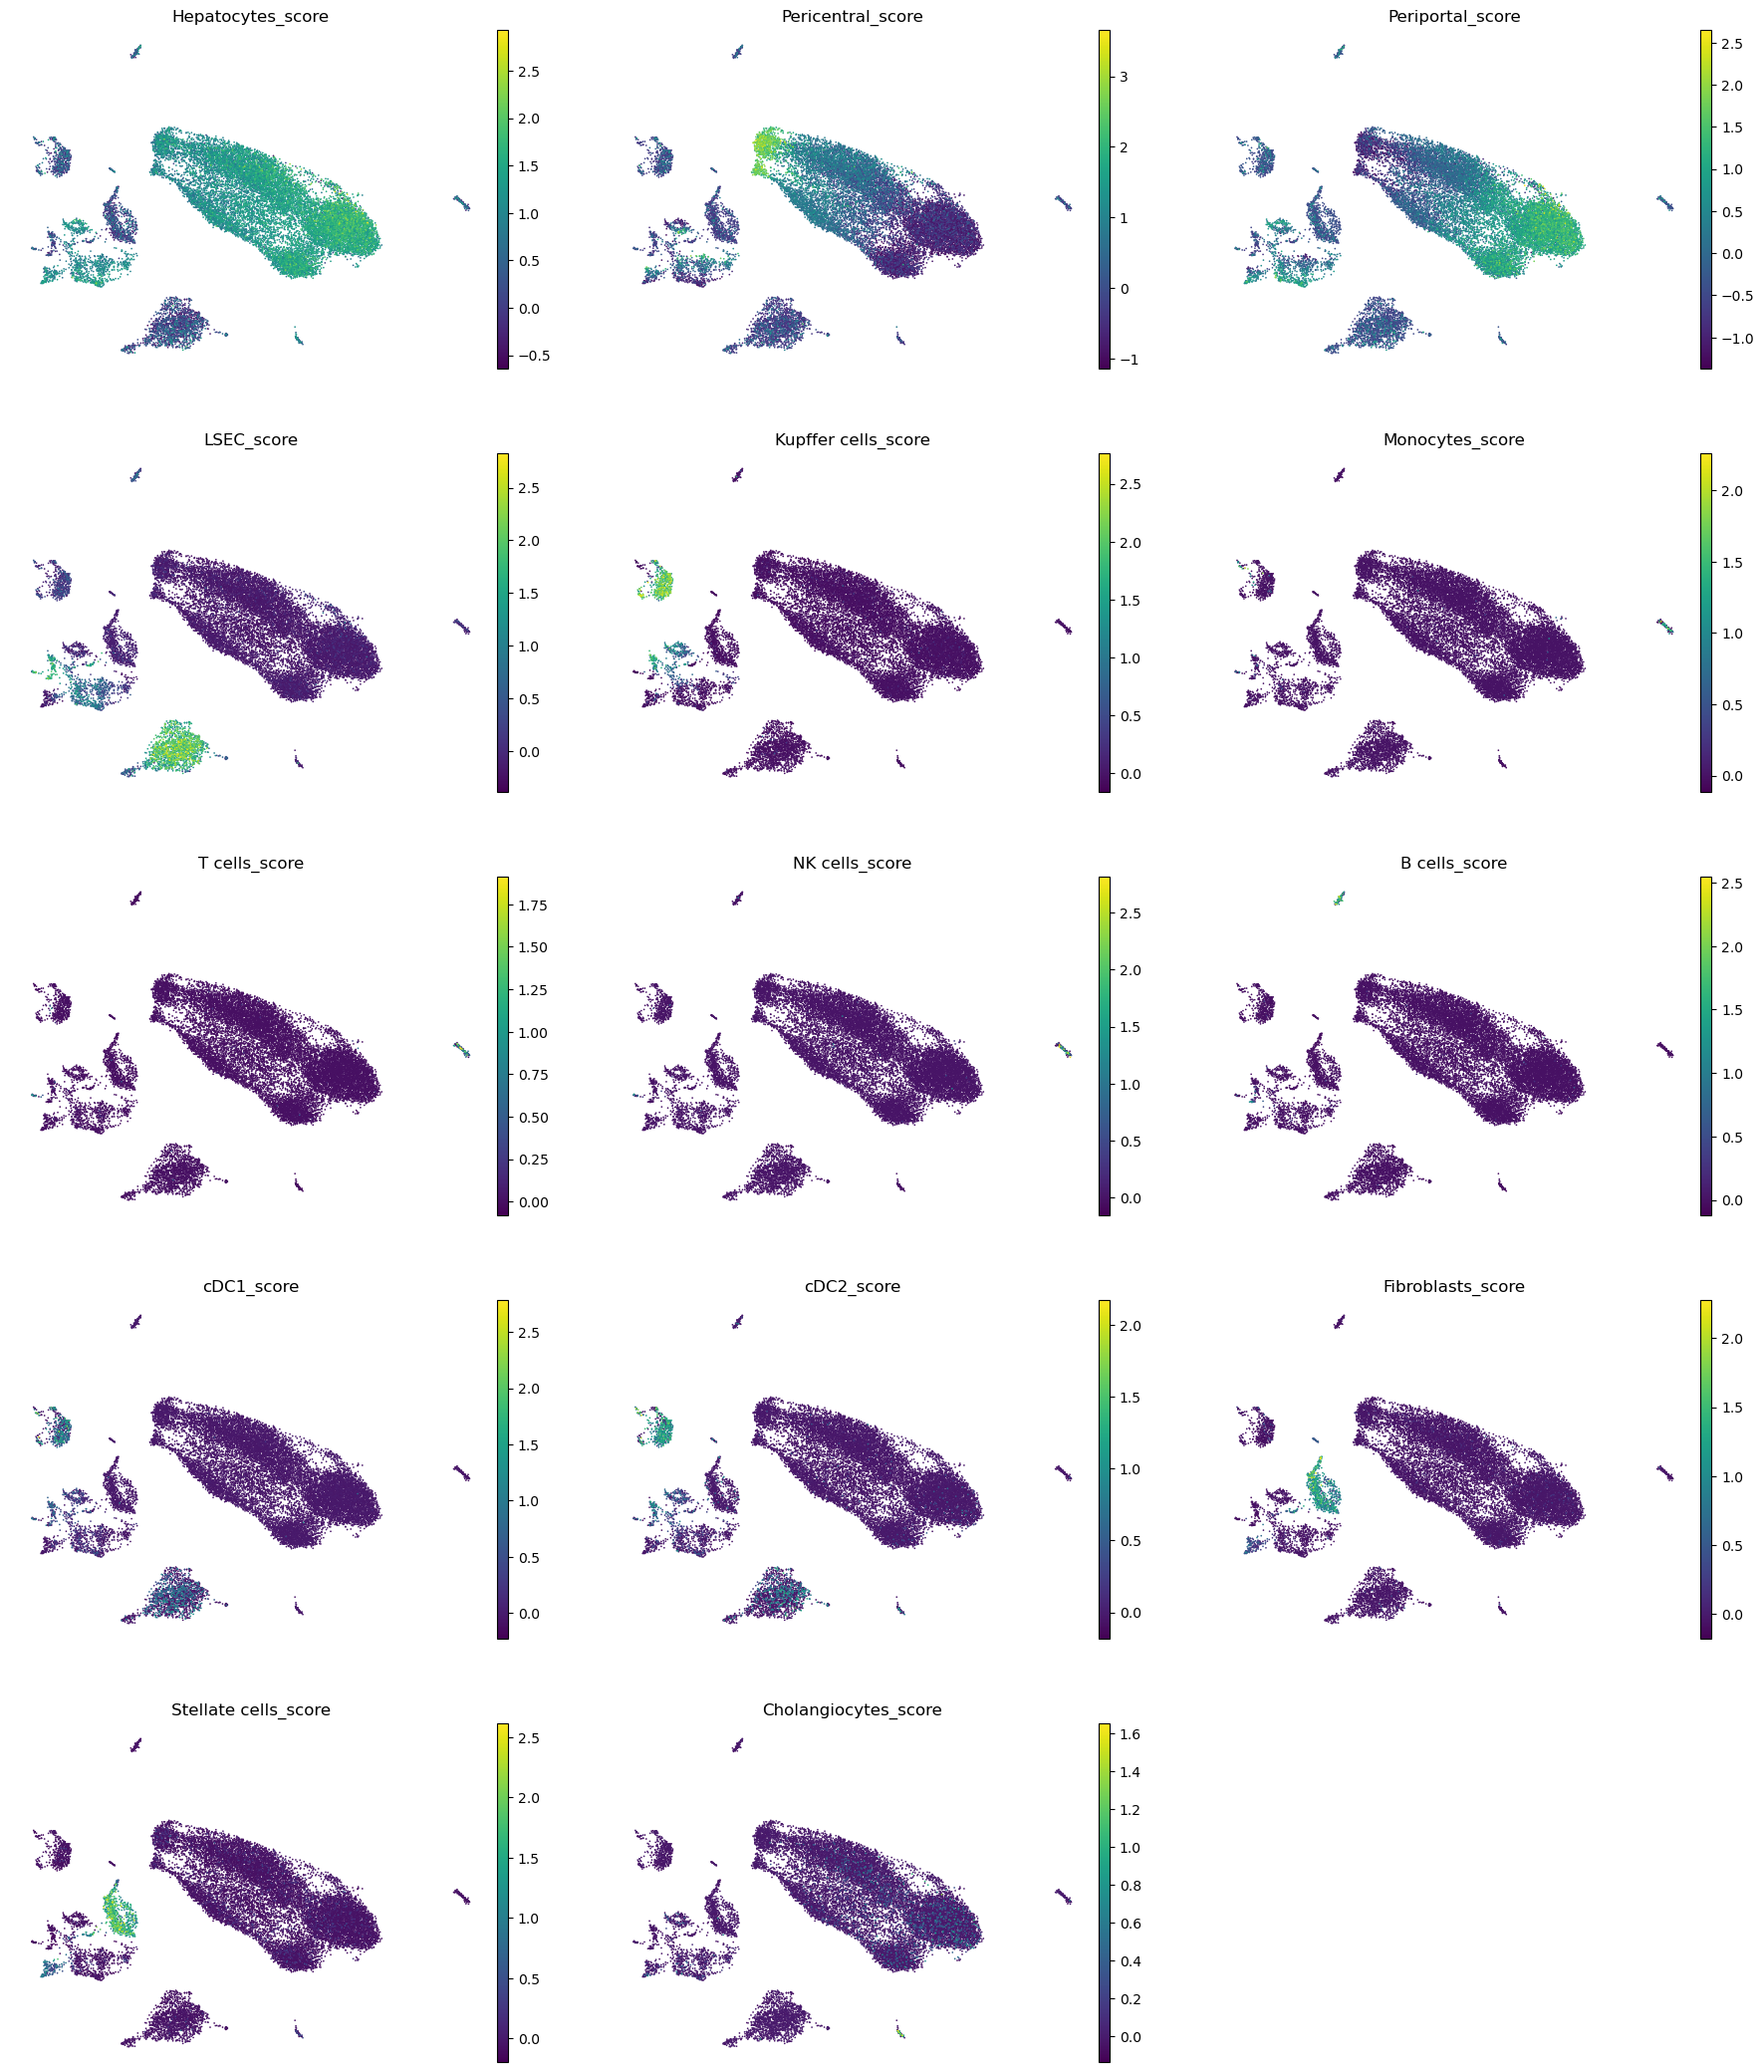

In [31]:
score_cols = []

for cell_type, genes in marker_dict_present.items():
    score_col = f"{cell_type}_score"
    sc.tl.score_genes(
        rna_filtered,
        gene_list=genes,
        score_name=score_col,
        use_raw=False,  # use the expression in rna_filtered.X
    )
    score_cols.append(score_col)

sc.pl.umap(
    rna_filtered,
    color=score_cols,
    ncols=3,
    cmap="viridis",
    frameon=False,
)

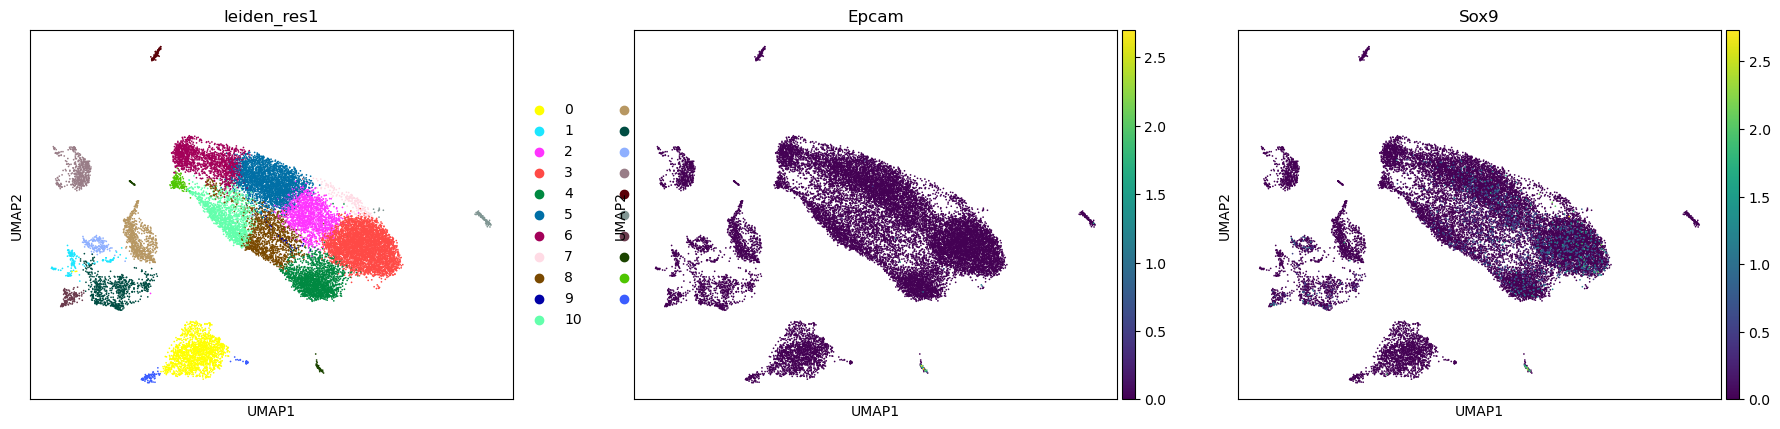

In [38]:
sc.pl.umap(
    rna_filtered,
    color=[
        "leiden_res1",
        "Epcam", "Sox9"
    ],
    use_raw=False,
    ncols=3,
)

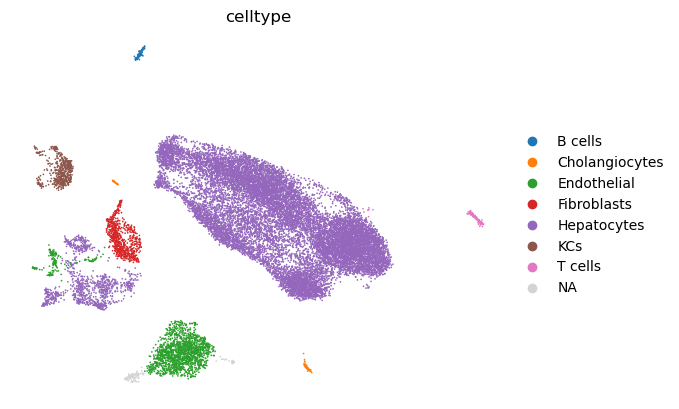

In [35]:
celltype_map = {
    "Hepatocytes":  [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 16, 17, 19],
    "Endothelial":  [0, 1],
    "KCs":          [14],
    "DCs":          [],
    "T cells":      [16],
    "B cells":      [15],
    "Fibroblasts":  [11],
    "Cholangiocytes": [18]
}

cluster_to_celltype = {
    str(c): ct for ct, clusters in celltype_map.items() for c in clusters
}

rna_filtered.obs["celltype"] = (
    rna_filtered.obs["leiden_res1"]
    .astype(str)
    .map(cluster_to_celltype)
    .astype("category")
)

# Plot UMAP with cell type labels
sc.pl.umap(
    rna_filtered,
    color=["celltype"],
    vmax="p99",
    frameon=False,
)

## Saving progress to disk

In [39]:
mu.write(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu/rna"), rna_filtered)
print(f"Saved RNA data to {SAMPLE_PROCESSED_DATA_DIR / f'{SAMPLE_NAME}.h5mu/rna'}")

Saved RNA data to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/liver_sample/liver_sample.h5mu/rna


---

# ATAC

In [40]:
atac = mdata.mod['atac']
atac  # an AnnData object

AnnData object with n_obs × n_vars = 24936 × 149393
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

## Preprocessing

### QC

Filter out cells with too few peaks and peaks detected in too few cells.

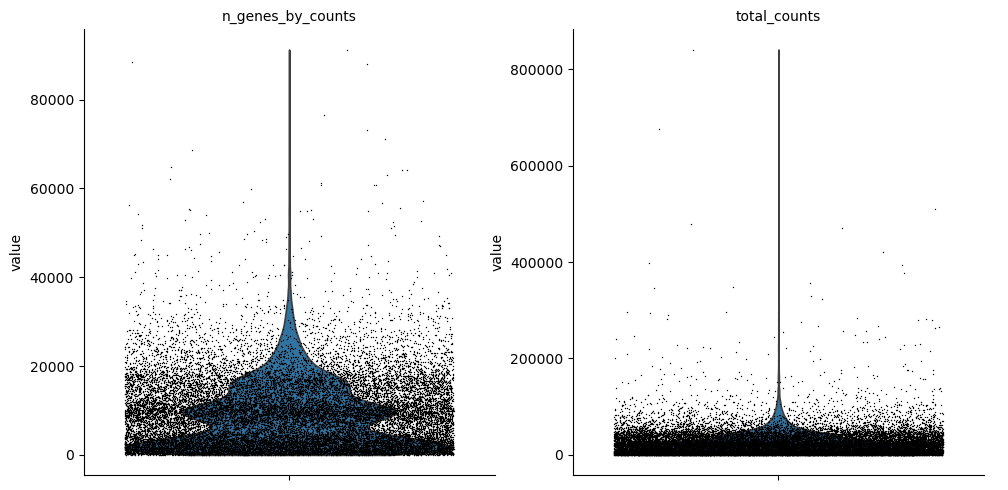

In [41]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(atac, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)

In [42]:
# Filter out cells that are out of 5 MADs
atac.obs["outlier"] = (
    is_outlier(atac, "n_genes_by_counts", 5)
    | is_outlier(atac, "total_counts", 5)
)
# Remove peaks that are not detected in at least MIN_CELLS_PER_PEAK cells
mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)

atac.obs.outlier.value_counts()

outlier
False    24304
True       632
Name: count, dtype: int64

In [43]:
print(f"Total number of cells: {atac.n_obs}")
atac_filtered = atac[(~atac.obs.outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {atac_filtered.n_obs}")

Total number of cells: 24936
Number of cells after filtering of low quality cells: 24304


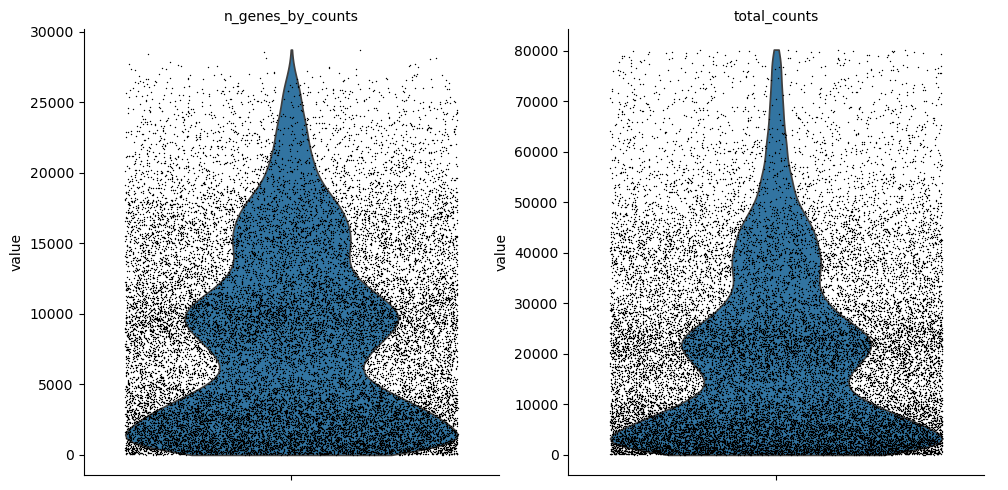

In [44]:
sc.pl.violin(atac_filtered, ['n_genes_by_counts', 'total_counts'], jitter=0.4, multi_panel=True)

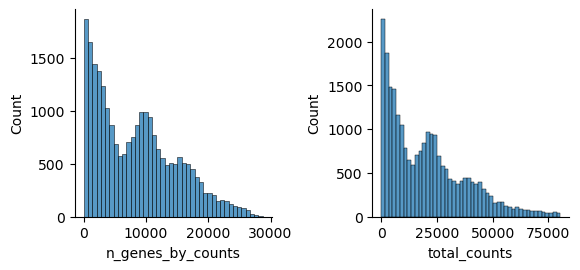

In [45]:
mu.pl.histogram(atac_filtered, ['n_genes_by_counts', 'total_counts'])

### ATAC-specific QC
There are a few expectations about how ATAC-seq data looks like as noted in the [hitchhiker’s guide to ATAC-seq data analysis](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-020-1929-3#citeas) for instance


#### Nucleosome Signal

Fragment size distribution typically reflects nucleosome binding pattern showing enrichment around values corresponding to fragments bound to a single nucleosome (between 147 bp and 294 bp) as well as nucleosome-free fragments (shorter than 147 bp).

In [46]:
if frag_path is not None:
    index_file = str(frag_path) + ".tbi"

    if Path(index_file).exists():
        print("Found index:", index_file)

    else:
        # Index the fragment file
        print("Index file not found. Creating index file...")
        pysam.tabix_index(
            str(frag_path),
            preset="bed",
            force=True
        )
        index_file = str(frag_path) + ".tbi"

    # Create the index file for the fragments
    tbx = pysam.TabixFile(str(frag_path))
    print(tbx.contigs[:20])

    # register the fragment file with the ATAC AnnData
    ac.tl.locate_fragments(atac_filtered, fragments=str(frag_path))

    print(atac_filtered.uns["files"])
    print(atac_filtered.uns["files"]["fragments"])
    # optional grouping column if you want one
    atac_filtered.obs["NS"] = 1

    def find_nonempty_region(tbx, chrom="chr1", window=1_000_000, max_end=200_000_000):
        for start in range(0, max_end, window):
            rows = list(tbx.fetch(chrom, start, start + window))
            if rows:
                return f"{chrom}:{start}-{start+window}", rows[0]
        return None, None

    region, example = find_nonempty_region(tbx, chrom="chr1")
    print(region, example)

    ac.pl.fragment_histogram(atac_filtered, region=region)
else:
    print("No fragment file provided, skipping fragment histogram plotting.")

No fragment file provided, skipping fragment histogram plotting.


### Normalization

In [47]:
# Save original counts
atac_filtered.layers["counts"] = atac_filtered.X

In [35]:
# ac.pp.tfidf(atac_filtered, scale_factor=1e4)

Here we will use the same log-normalisation and PCA that we are used to from scRNA-seq analysis. We notice on this data it yields PC & UMAP spaces similar to the one generated on scRNA-seq counts.

In [48]:
sc.pp.normalize_per_cell(atac_filtered, counts_per_cell_after=1e4)
sc.pp.log1p(atac_filtered)

/tmp/ipykernel_3557312/1252468221.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(atac_filtered, counts_per_cell_after=1e4)


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


In [49]:
ac.tl.lsi(atac_filtered)

atac_filtered.obsm['X_lsi'] = atac_filtered.obsm['X_lsi'][:,1:]
atac_filtered.varm["LSI"] = atac_filtered.varm["LSI"][:,1:]
atac_filtered.uns["lsi"]["stdev"] = atac_filtered.uns["lsi"]["stdev"][1:]

In [50]:
sc.pp.neighbors(atac_filtered, use_rep="X_lsi", n_neighbors=10, n_pcs=30)

### PCA

For this notebook, we are using PCA on the log-normalised counts in atac.X as described above.

### Neighbors

In [51]:
atac_filtered.obs["donor"] = "mouse_" + atac_filtered.obs_names.str.rsplit("-", n=1).str[1]

In [52]:
# harmony on the trimmed LSI
ho = harmonypy.run_harmony(
    atac_filtered.obsm["X_lsi"].astype(np.float64), atac_filtered.obs, "donor"
)
Z = np.asarray(ho.Z_corr)
if Z.shape[0] != atac_filtered.n_obs:
    Z = Z.T
atac_filtered.obsm["X_lsi_harmony"] = Z

2026-09-25 11:23:51,748 - harmonypy - INFO - Running Harmony
2026-09-25 11:23:51,749 - harmonypy - INFO -   Parameters:
2026-09-25 11:23:51,749 - harmonypy - INFO -     max_iter_harmony: 10
2026-09-25 11:23:51,750 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-25 11:23:51,751 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-25 11:23:51,751 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-25 11:23:51,752 - harmonypy - INFO -     nclust: 100
2026-09-25 11:23:51,757 - harmonypy - INFO -     block_size: 0.05
2026-09-25 11:23:51,758 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-25 11:23:51,758 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-09-25 11:23:51,759 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-25 11:23:51,759 - harmonypy - INFO -     verbose: True
2026-09-25 11:23:51,759 - harmonypy - INFO -     random_state: 0
2026-09-25 11:23:51,760 - harmonypy - INFO -   Data: 49 PCs × 24304 cells


2026-09-25 11:23:51,760 - harmonypy - INFO -   Batch variables: ['donor']
2026-09-25 11:23:51,782 - harmonypy - INFO - Computing initial centroids...
2026-09-25 11:23:52,551 - harmonypy - INFO - Initialization complete.
2026-09-25 11:23:52,553 - harmonypy - INFO - Iteration 1 of 10
2026-09-25 11:23:53,068 - harmonypy - INFO - Iteration 2 of 10
2026-09-25 11:23:53,612 - harmonypy - INFO - Converged after 2 iterations


In [53]:
sc.pp.neighbors(atac_filtered, n_neighbors=10, n_pcs=10)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 149390 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


### Non-linear dimensionality reduction and clustering

To stay comparable to the gene expression notebook, we will use leiden to cluster cells. We’ll use UMAP latent space for visualisation below.

In [54]:
sc.tl.umap(atac_filtered, spread=1., min_dist=.5, random_state=11)
sc.tl.leiden(atac_filtered, flavor="igraph", n_iterations=2)

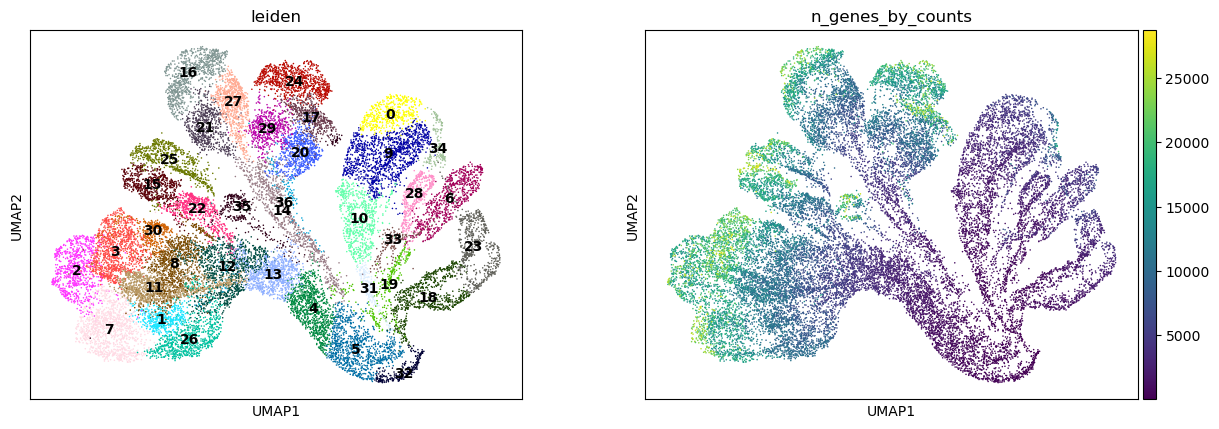

In [55]:
sc.pl.umap(atac_filtered, color=["leiden", "n_genes_by_counts"], legend_loc="on data")

## Saving progress to disk

In [56]:
mu.write(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu/atac"), atac_filtered)

---

# Integrating Gene Expression and Chromatin Accessibility

In this section, we will see how to learn a latent space jointly on two omics.

In [57]:
mdata = mu.read(str(SAMPLE_PROCESSED_DATA_DIR / f"{SAMPLE_NAME}.h5mu"))
mu.pp.intersect_obs(mdata)
mdata

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:

MuData object with n_obs × n_vars = 19691 × 168350
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
  2 modalities
    rna:	19691 x 18960
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'donor', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'Hepatocytes_score', 'Endothelial_score', 'KCs_score', 'DCs_score', 'T cells_score', 'B cells_score', 'Fibroblasts_score', 'Pericentral_score', 'Periportal_score', 'LSEC_score', 'Kupffer cells_score', 'Monocytes_score', 'NK cells_score', 'cDC1_score', 'cDC2_score', 'Stellate cells_score', 'Cholangiocytes_score', 'celltype'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'celltype_colors', 'donor_colors', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'scrublet', 'tsne', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_tsne', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    atac:	19691 x 149390
      obs:	'n_genes_by_counts', 'total_counts', 'outlier', 'n_counts', 'donor', 'leiden'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
      uns:	'leiden', 'leiden_colors', 'log1p', 'lsi', 'neighbors', 'pca', 'umap'
      obsm:	'X_lsi', 'X_lsi_harmony', 'X_pca', 'X_umap'
      varm:	'LSI', 'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'

## Peak-TG Distance

In [58]:
import pybedtools

MAX_PEAK_DISTANCE = 100_000
TSS_DECAY = 20_000
NEAREST_GENE_ONLY = False


def format_peaks(peak_ids: pd.Index | pd.Series) -> pd.DataFrame:
    """Parse peak IDs such as chr1:100-200 or chr1-100-200."""
    peak_ids = pd.Index(peak_ids).astype(str)
    peak_series = pd.Series(peak_ids, index=peak_ids, name="original_peak_id")

    valid_chr = peak_series.str.contains("chr", regex=False, na=False)
    peak_series = peak_series[valid_chr]

    if peak_series.empty:
        raise ValueError("No peak IDs containing 'chr' were found.")

    parsed = peak_series.str.extract(
        r".*?(?P<chrom>chr[^\s:-]+)(?::|-)(?P<start>\d+)-(?P<end>\d+)\s*$"
    )
    parsed.index = peak_series.index

    missing = parsed[["chrom", "start", "end"]].isna().any(axis=1)
    if missing.any():
        bed_like = peak_series.loc[missing].str.extract(
            r"^\s*(?P<chrom>\S+)\s+(?P<start>\d+)\s+(?P<end>\d+)(?:\s|$)"
        )
        bed_like.index = peak_series.loc[missing].index
        parsed.loc[missing, ["chrom", "start", "end"]] = bed_like[
            ["chrom", "start", "end"]
        ]

    malformed = parsed[["chrom", "start", "end"]].isna().any(axis=1)
    if malformed.any():
        bad = peak_series.loc[malformed].head(3).tolist()
        raise ValueError(f"Malformed peak IDs, e.g. {bad}")

    peak_df = pd.DataFrame(
        {
            "chrom": parsed["chrom"].astype(str),
            "start": pd.to_numeric(parsed["start"]).astype(np.int64),
            "end": pd.to_numeric(parsed["end"]).astype(np.int64),
        },
        index=parsed.index,
    )

    invalid_coordinates = peak_df["end"] <= peak_df["start"]
    if invalid_coordinates.any():
        bad = peak_df.index[invalid_coordinates].tolist()[:3]
        raise ValueError(f"Peaks have end <= start, e.g. {bad}")

    # This preserves the exact ATAC var_name for mapping results back into .var.
    peak_df["peak_id"] = peak_df.index.astype(str)

    return peak_df.reset_index(drop=True)


def find_genes_near_peaks(
    peak_bed: pybedtools.BedTool,
    tss_bed: pybedtools.BedTool,
    distance_cutoff: int,
) -> pd.DataFrame:
    """
    Find peak-TSS pairs within distance_cutoff.

    Assumes tss_bed has four columns:
        chromosome, start, end, gene_id

    Returns one row per (peak, gene) pair, sorted by peak then distance.
    """
    overlaps = peak_bed.window(tss_bed, w=distance_cutoff)

    columns = [
        "peak_chr",
        "peak_start",
        "peak_end",
        "peak_id",
        "gene_chr",
        "gene_start",
        "gene_end",
        "target_id",
    ]

    hits = overlaps.to_dataframe(names=columns, low_memory=False)

    if hits.empty:
        return pd.DataFrame(
            columns=[
                "peak_id",
                "target_id",
                "TSS_dist",
                "TSS_dist_score",
            ]
        )

    numeric_columns = [
        "peak_start",
        "peak_end",
        "gene_start",
        "gene_end",
    ]
    for column in numeric_columns:
        hits[column] = pd.to_numeric(hits[column], errors="coerce")

    hits = hits.dropna(subset=numeric_columns).copy()

    # Distance from the peak interval to the TSS interval:
    #   0 if the TSS overlaps the peak;
    #   otherwise distance to the closest peak boundary.
    hits["TSS_dist"] = np.maximum.reduce(
        [
            hits["gene_start"].to_numpy() - hits["peak_end"].to_numpy(),
            hits["peak_start"].to_numpy() - hits["gene_end"].to_numpy(),
            np.zeros(len(hits)),
        ]
    ).astype(np.int64)

    hits = hits[hits["TSS_dist"] <= distance_cutoff].copy()
    hits["target_id"] = hits["target_id"].astype(str).str.upper()

    hits = hits.sort_values(
        ["peak_id", "TSS_dist", "target_id"],
        kind="stable",
    )

    if NEAREST_GENE_ONLY:
        hits = hits.drop_duplicates("peak_id", keep="first")
    else:
        # The TSS bed is transcript-level, so one gene contributes many TSS
        # entries and a peak can hit the same gene several times at different
        # distances. Under nearest-only this never surfaced, because the
        # drop_duplicates above collapsed it. Keep the closest TSS per
        # (peak, gene) pair so each pair appears exactly once.
        hits = hits.drop_duplicates(["peak_id", "target_id"], keep="first")

    hits["TSS_dist_score"] = np.exp(
        -hits["TSS_dist"] / TSS_DECAY
    )

    return hits


def add_peak_gene_distances(
    mdata,
    tss_bed_file,
    atac_key: str = "atac",
    overwrite: bool = False,
):
    """
    Add peak-gene distance information to mdata[atac_key].

    Adds to .var (one value per peak, its nearest gene, unchanged from before):
        nearest_gene
        TSS_dist
        TSS_dist_score

    Adds to .uns["peak_gene_links"] (every link inside the window):
        genes        unique gene names, sorted
        gene_ptr     CSR-style offsets, length len(genes) + 1
        peak_idx     column position in atac.var_names, for each link
        TSS_dist     distance for each link
        TSS_dist_score

    Links are grouped by gene and sorted by distance within a gene, so the
    peaks for gene g are peak_idx[gene_ptr[g]:gene_ptr[g + 1]], already in the
    order a max_peaks_per_tg cap wants to slice. That replaces a full scan of
    var["nearest_gene"] per gene with a slice.

    Returns the filtered ATAC modality.
    """
    if atac_key not in mdata.mod:
        raise KeyError(
            f"Modality {atac_key!r} was not found. "
            f"Available modalities: {list(mdata.mod.keys())}"
        )

    tss_bed_file = str(tss_bed_file)
    atac = mdata[atac_key]

    output_columns = [
        "nearest_gene",
        "TSS_dist",
        "TSS_dist_score",
    ]
    existing = [column for column in output_columns if column in atac.var.columns]

    if existing and not overwrite:
        raise ValueError(
            f"ATAC .var already contains {existing}. "
            "Use overwrite=True to replace them."
        )

    print(f"ATAC features: {atac.n_vars:,}")
    print(f"TSS annotation: {tss_bed_file}")

    peak_locs = format_peaks(atac.var_names)

    peak_bed = pybedtools.BedTool.from_dataframe(
        peak_locs[["chrom", "start", "end", "peak_id"]]
    )
    tss_bed = pybedtools.BedTool(tss_bed_file)

    links = find_genes_near_peaks(
        peak_bed,
        tss_bed,
        distance_cutoff=MAX_PEAK_DISTANCE,
    )

    if links.empty:
        raise ValueError("No peak-gene links were found inside the window.")

    # Nearest gene per peak: the first row of each peak's block, since
    # find_genes_near_peaks sorted by peak then distance.
    nearest = links.drop_duplicates("peak_id", keep="first").set_index("peak_id")

    atac.var["nearest_gene"] = atac.var_names.map(nearest["target_id"])

    atac.var["TSS_dist"] = pd.array(
        atac.var_names.map(nearest["TSS_dist"]),
        dtype="Int64",
    )

    atac.var["TSS_dist_score"] = atac.var_names.map(
        nearest["TSS_dist_score"]
    ).astype(float)

    # A peak with any link necessarily has a nearest one, so this filter is
    # identical to the nearest-only version and the peak universe is unchanged.
    keep_peaks = atac.var["nearest_gene"].notna().to_numpy()
    atac = atac[:, keep_peaks].copy()

    print(f"Retained {atac.n_vars:,} peaks with a nearby gene")

    # ---- Full link table, indexed against the FILTERED peak order ----
    peak_position = pd.Series(
        np.arange(atac.n_vars, dtype=np.int32),
        index=atac.var_names,
    )

    links = links[links["peak_id"].isin(peak_position.index)].copy()
    links["peak_idx"] = links["peak_id"].map(peak_position).astype(np.int32)

    genes = np.sort(links["target_id"].unique())
    gene_position = pd.Series(np.arange(len(genes), dtype=np.int32), index=genes)
    links["gene_idx"] = links["target_id"].map(gene_position).astype(np.int32)

    # Group by gene, closest peak first, so a per-gene slice is contiguous.
    links = links.sort_values(["gene_idx", "TSS_dist"], kind="stable")

    counts = np.bincount(links["gene_idx"].to_numpy(), minlength=len(genes))
    gene_ptr = np.zeros(len(genes) + 1, dtype=np.int64)
    np.cumsum(counts, out=gene_ptr[1:])

    atac.uns["peak_gene_links"] = {
        "peaks": np.asarray(atac.var_names, dtype=object),
        "genes": np.asarray(genes, dtype=object),
        "gene_ptr": gene_ptr,
        "peak_idx": links["peak_idx"].to_numpy(np.int32),
        "TSS_dist": links["TSS_dist"].to_numpy(np.int32),
        "TSS_dist_score": links["TSS_dist_score"].to_numpy(np.float32),
    }

    atac.uns["peak_gene_distance_params"] = {
        "tss_annotation": tss_bed_file,
        "maximum_distance": MAX_PEAK_DISTANCE,
        "decay": TSS_DECAY,
        "nearest_gene_only": NEAREST_GENE_ONLY,
        "distance_definition": "minimum interval distance between peak and TSS",
    }

    peaks_per_gene = np.diff(gene_ptr)
    print(
        f"Annotated {len(genes):,} genes with {len(links):,} links "
        f"(median {np.median(peaks_per_gene):.0f}, "
        f"mean {peaks_per_gene.mean():.1f}, max {peaks_per_gene.max():,} peaks per gene)"
    )
    print(
        f"Nearest-gene only would have reached "
        f"{atac.var['nearest_gene'].nunique():,} genes"
    )

    return atac


mdata.mod["atac"] = add_peak_gene_distances(
    mdata, tss_bed_file=tss_path, atac_key="atac", overwrite=True
)


ATAC features: 149,390
TSS annotation: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/genome_data/genome_annotation/mm10/mm10_gene_tss.bed
Retained 147,471 peaks with a nearby gene
Annotated 68,060 genes with 1,276,632 links (median 18, mean 18.8, max 130 peaks per gene)
Nearest-gene only would have reached 40,871 genes


## Ranking genes and peaks

In [59]:
print(f"Num cells: {mdata.n_obs}")
print(f"Num genes: {mdata['rna'].n_vars}")
print(f"Num peaks: {mdata['atac'].n_vars}")

Num cells: 19691
Num genes: 18960
Num peaks: 147471


# Save Processed Data

In [60]:
mdata_file = SAMPLE_PROCESSED_DATA_DIR / "multiome_processed.h5mu"

mdata.write(mdata_file)

print(f"Saved MuData object to {mdata_file}")

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


Saved MuData object to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/processed/mouse_liver/liver_sample/multiome_processed.h5mu


In [61]:
from pathlib import Path
import subprocess
import sys

NOTEBOOK_PATH = (
    PROJECT_DIR
    / "dev/notebooks/muon_preprocessing"
    / "mouse_liver_updated_muon_multiomic_preprocessing.ipynb"
)

HTML_DIR = NOTEBOOK_PATH.parent / "preprocessing_html"
HTML_DIR.mkdir(parents=True, exist_ok=True)

html_name = f"{SAMPLE_NAME}_preprocessing"

subprocess.run(
    [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        "--to",
        "html",
        "--output",
        html_name,
        "--output-dir",
        str(HTML_DIR),
        str(NOTEBOOK_PATH),
    ],
    check=True,
)

print(f"Saved {HTML_DIR / f'{html_name}.html'}")

[NbConvertApp] Converting notebook /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/muon_preprocessing/mouse_liver_updated_muon_multiomic_preprocessing.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 14 image(s).
[NbConvertApp] Writing 5018866 bytes to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/muon_preprocessing/preprocessing_html/liver_sample_preprocessing.html


Saved /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/muon_preprocessing/preprocessing_html/liver_sample_preprocessing.html
